# SDR Family Analysis

## Identifying SDR Family Proteins

In [1]:
import json
import pandas as pd

with open("data/GeneOntology/test_interpro.json", "r") as f:
    interpro = json.load(f)

rows = []

for protein_id, entry in interpro.items():
    
    results = entry.get("results", [])
    
    for ipr in results:
        
        metadata = ipr.get("metadata", {})
        structures = ipr.get("structures", [])
        
        # If no structures exist, still record annotation
        if not structures:
            rows.append({
                "protein_id": protein_id,
                "chain": None,
                "interpro_accession": metadata.get("accession"),
                "interpro_name": metadata.get("name"),
                "type": metadata.get("type"),
                "source_database": metadata.get("source_database"),
            })
        else:
            for structure in structures:
                rows.append({
                    "protein_id": protein_id,
                    "chain": structure.get("chain"),
                    "interpro_accession": metadata.get("accession"),
                    "interpro_name": metadata.get("name"),
                    "type": metadata.get("type"),
                    "source_database": metadata.get("source_database"),
                })

df = pd.DataFrame(rows)

print("Total rows:", len(df))
print("Unique proteins:", df["protein_id"].nunique())
print("Unique chains:", df[["protein_id","chain"]].drop_duplicates().shape[0])
print("Unique InterPro entries:", df["interpro_accession"].nunique())

df.head()


Total rows: 52426
Unique proteins: 3009
Unique chains: 15299
Unique InterPro entries: 6493


,protein_id,chain,interpro_accession,interpro_name,type,source_database
0,3ONG,B,IPR000608,Ubiquitin-conjugating enzyme E2,domain,interpro
1,3ONG,D,IPR000608,Ubiquitin-conjugating enzyme E2,domain,interpro
2,3ONG,B,IPR016135,Ubiquitin-conjugating enzyme/RWD-like,homologous_superfamily,interpro
3,3ONG,D,IPR016135,Ubiquitin-conjugating enzyme/RWD-like,homologous_superfamily,interpro
4,3ONG,B,IPR023313,"Ubiquitin-conjugating enzyme, active site",active_site,interpro


In [2]:
family_df = df[df["type"] == "family"]

family_counts = (
    family_df
    .groupby(["interpro_accession", "interpro_name"])
    .protein_id
    .nunique()
    .reset_index(name="num_proteins")
    .sort_values("num_proteins", ascending=False)
)

family_counts.head(20)


,interpro_accession,interpro_name,num_proteins
110,IPR000597,Large ribosomal subunit protein uL3,88
36,IPR000218,Large ribosomal subunit protein uL14,86
128,IPR000702,Large ribosomal subunit protein uL6-like,79
49,IPR000266,Small ribosomal subunit protein uS17,78
108,IPR000589,Small ribosomal subunit protein uS15,77
41,IPR000235,Small ribosomal subunit protein uS7,76
898,IPR006059,Bacterial-type extracellular solute-binding pr...,76
899,IPR006060,"Maltose/Cyclodextrin ABC transporter, substrat...",75
112,IPR000630,Small ribosomal subunit protein uS8,75
144,IPR000754,Small ribosomal subunit protein uS9,65


In [3]:
selected_family = "IPR002347"

proteins_in_family = (
    family_df[family_df["interpro_accession"] == selected_family]
)

proteins_in_family

,protein_id,chain,interpro_accession,interpro_name,type,source_database
44,2FWM,X,IPR002347,Short-chain dehydrogenase/reductase SDR,family,interpro
800,3BHI,A,IPR002347,Short-chain dehydrogenase/reductase SDR,family,interpro
3608,4JQC,A,IPR002347,Short-chain dehydrogenase/reductase SDR,family,interpro
3609,4JQC,B,IPR002347,Short-chain dehydrogenase/reductase SDR,family,interpro
6881,5JS6,A,IPR002347,Short-chain dehydrogenase/reductase SDR,family,interpro
...,...,...,...,...,...,...
50635,2O23,B,IPR002347,Short-chain dehydrogenase/reductase SDR,family,interpro
52087,4HWK,A,IPR002347,Short-chain dehydrogenase/reductase SDR,family,interpro
52088,4HWK,B,IPR002347,Short-chain dehydrogenase/reductase SDR,family,interpro
52089,4HWK,C,IPR002347,Short-chain dehydrogenase/reductase SDR,family,interpro


In [4]:
proteins_in_family[["protein_id", "chain"]].drop_duplicates().to_csv("selected_sdr_proteins.csv", index=False)

## Defining Visualisation Tools

In [5]:
from collections import defaultdict

def get_residue_ids(df, pdb_id):
    row = df[df["pdb_id"] == pdb_id].iloc[0]
    residue_ids = [
            int(x.strip())
            for x in row['residue_ids'].split(',')
            if x.strip() != ''
        ]
    return residue_ids

def get_proto_ids(df, pdb_id):
    row = df[df["pdb_id"] == pdb_id].iloc[0]
    return row['protos']

def group_residues_by_proto(residue_ids, proto_ids):
    """
    residue_ids: list[int]
    proto_ids:   list[int | str]
    """
    assert len(residue_ids) == len(proto_ids)

    proto_to_residues = defaultdict(list)
    for resi, proto in zip(residue_ids, proto_ids):
        proto_to_residues[proto].append(resi)

    return proto_to_residues


In [6]:
import pandas as pd

# Residue to prototype mapping

def add_residue_to_prototype_mapping(segment_assignments, prototype_assignments):
    pdb_id_segment_to_prototype = {}
    
    for _, row in prototype_assignments.iterrows():
        key = (row['pdb_id'], row['segment_k'])
        pdb_id_segment_to_prototype[key] = row['proto']
    
    out = segment_assignments.copy()

    def parse_and_map(row):
        cluster_ids = [
            int(x.strip())
            for x in row['cluster_ids'].split(',')
            if x.strip() != ''
        ]
        return [
            pdb_id_segment_to_prototype.get((row['pdb_id'], cid))
            for cid in cluster_ids
        ]

    out['protos'] = out.apply(parse_and_map, axis=1)
    return out

In [7]:
import numpy as np
from sklearn.decomposition import PCA

def build_global_color_model(centroids):
    """
    centroids: (K, d)
    """

    # 1. Fit PCA on centroids
    pca = PCA(n_components=3)
    centroid_pca = pca.fit_transform(centroids)  # (K, 3)

    # 2. Normalize PCA components globally to [0, 1]
    rgb_min = centroid_pca.min(axis=0)
    rgb_max = centroid_pca.max(axis=0)

    centroid_rgb = (centroid_pca - rgb_min) / (rgb_max - rgb_min + 1e-8)
    centroid_rgb = np.clip(centroid_rgb, 0, 1)

    return {
        "pca": pca,
        "centroid_rgb": centroid_rgb,
        "centroids": centroids
    }


In [8]:
def proto_id_to_color(proto_ids, color_model):
    proto_to_color = dict()
    for proto_id in proto_ids:
        if proto_id in proto_to_color or proto_id is None:
            continue
        r, g, b = color_model["centroid_rgb"][proto_id]
        hex_color = f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}"
        proto_to_color[proto_id] = hex_color
    return proto_to_color

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_sequence_colors(pdb_id, proto_to_residues, proto_to_color, chain_length, filename=None):
    """
    Visualizes the protein sequence as a horizontal bar colored by proto_ids.
    
    Args:
        pdb_id: Protein identifier
        proto_to_residues: Dict mapping prototype IDs to residue lists
        proto_to_color: Dict mapping prototype IDs to color hex codes
        chain_length: Length of the protein chain
        filename: Optional filename to save the figure (e.g., "output.png")
    """
    fig, ax = plt.subplots(figsize=(15, 2))
    
    # 1. Create a background gray bar for the whole sequence
    ax.add_patch(patches.Rectangle((1, 0), chain_length, 1, color='lightgray', label='Unassigned'))

    # 2. Overlay the colored segments
    for proto, residues in proto_to_residues.items():
        if proto is not None:
            color = proto_to_color[proto]
            for res_id in residues:
                # We draw a small vertical sliver for each residue
                ax.add_patch(patches.Rectangle((res_id, 0), 1, 1, color=color))

    # Formatting the plot
    ax.set_xlim(0, chain_length + 1)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel('Residue Index', fontsize=12)
    ax.set_title(f'Protein Sequence Segmentation Map for {pdb_id}', fontsize=14)
    
    # Optional: Remove spines for a cleaner look
    for spine in ["top", "left", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    
    # Save if filename is provided
    if filename is not None:
        plt.savefig(f"{filename}.png", dpi=150, bbox_inches='tight')
        print(f"Saved plot to {filename}")
    
    plt.show()

In [10]:
from IPython.display import HTML, display

def show_colors_html(proto_to_color):
    html = "<div style='display:flex; flex-wrap:wrap;'>"
    for proto, color in proto_to_color.items():
        html += (
            f"<div style='width:120px; margin:4px; "
            f"background:{color}; color:black; "
            f"padding:6px; text-align:center; "
            f"border:1px solid #ccc;'>"
            f"{proto}<br>{color}</div>"
        )
    html += "</div>"
    display(HTML(html))

## Loading model results

In [11]:
results_folder = "results_04_02"
model_name = "puffin_K64_v4"
model_k = "K1024"

In [12]:
selected_sdr_proteins = pd.read_csv("selected_sdr_proteins.csv")

In [13]:
prototype_assignments = pd.read_csv(f"{results_folder}/prototypes/{model_name}/{model_k}/assignments_test.csv")
segment_assignments = pd.read_csv(f"{results_folder}/segments/{model_name}/test/test_residue_assignments.csv")
segment_assignments_with_protos = add_residue_to_prototype_mapping(segment_assignments, prototype_assignments)
enrichment_df = pd.read_csv(f"{results_folder}/prototypes/{model_name}/{model_k}/eval/go_enrichment_train_all.csv")

centroids = np.load(f"{results_folder}/prototypes/{model_name}/{model_k}/train_centroids.npy")

In [14]:
color_model = build_global_color_model(centroids)

## Plotting clusters on sequence

Saved plot to sdr_proteins_puffin\2FWM-X_X


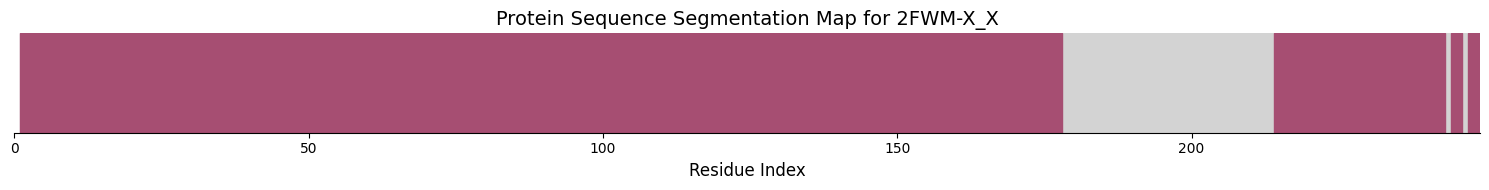

['IPR003560', 'IPR002347', 'IPR020904', 'IPR036291']
Saved plot to sdr_proteins_puffin\3BHI-A_A


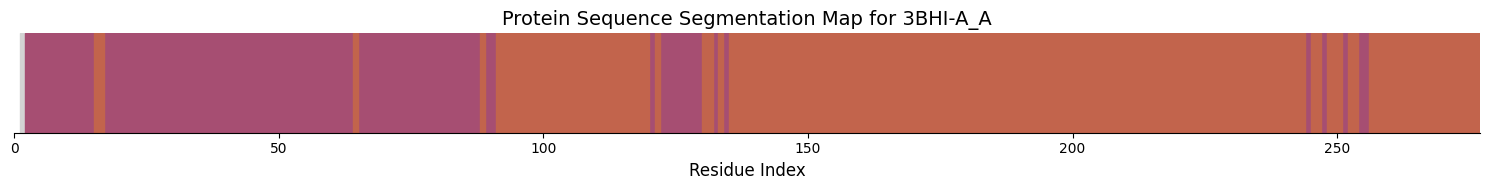

['IPR002347', 'IPR045313', 'IPR020904', 'IPR036291']
Saved plot to sdr_proteins_puffin\4JQC-A_A


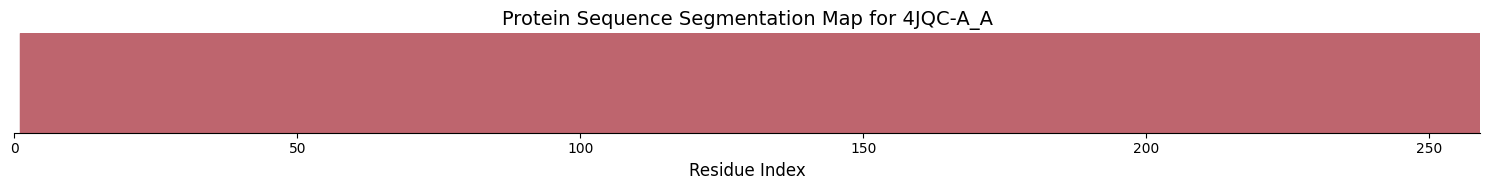

['IPR002347', 'IPR036291', 'IPR014358']
Saved plot to sdr_proteins_puffin\5JS6-A_A


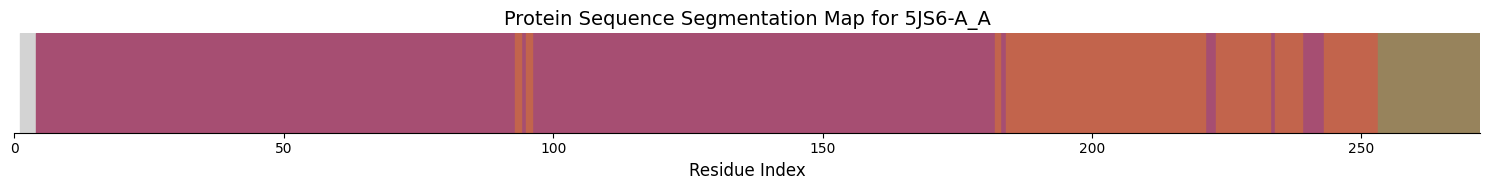

['IPR002347', 'IPR020904', 'IPR036291']
Saved plot to sdr_proteins_puffin\2HRB-A_A


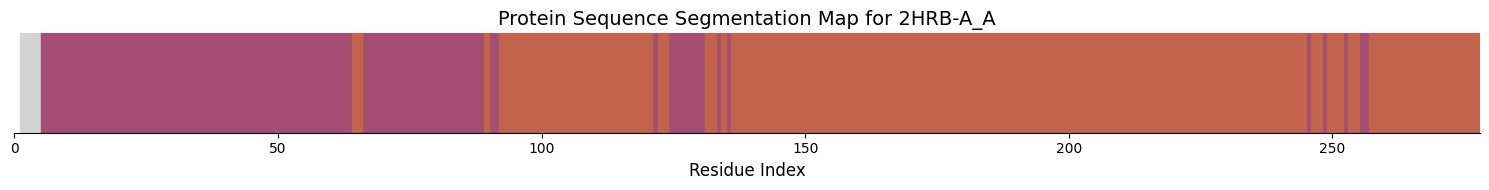

['IPR002347', 'IPR045313', 'IPR020904', 'IPR036291']
Saved plot to sdr_proteins_puffin\2AG5-A_A


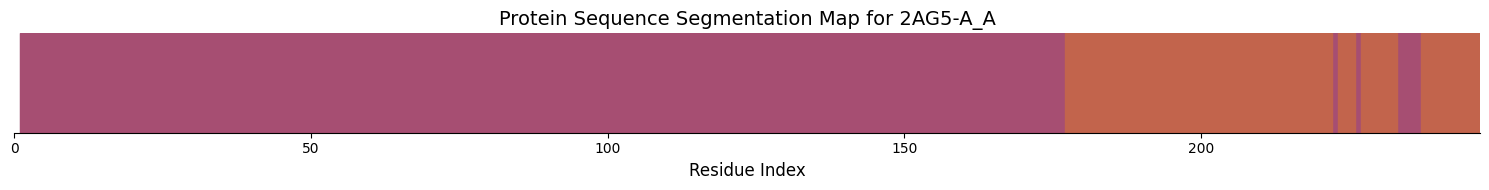

['IPR051122', 'IPR002347', 'IPR020904', 'IPR036291']
Saved plot to sdr_proteins_puffin\5CFZ-A_A


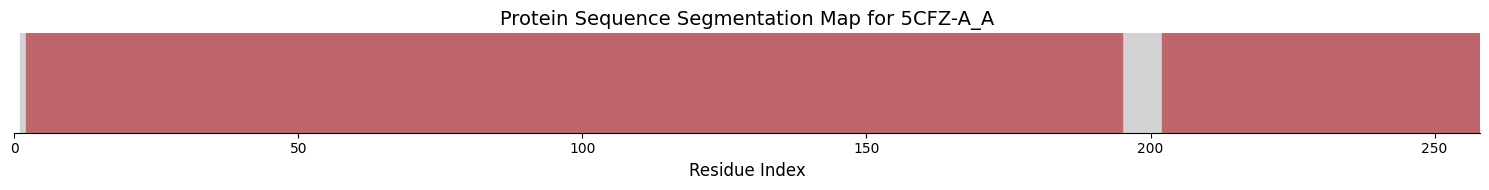

['IPR002347', 'IPR036291', 'IPR014358']
Saved plot to sdr_proteins_puffin\2GDZ-A_A


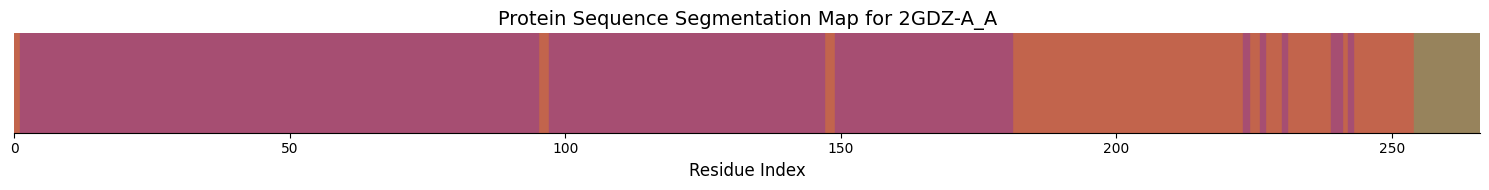

['IPR002347', 'IPR020904', 'IPR036291']
Saved plot to sdr_proteins_puffin\4Z3K-A_A


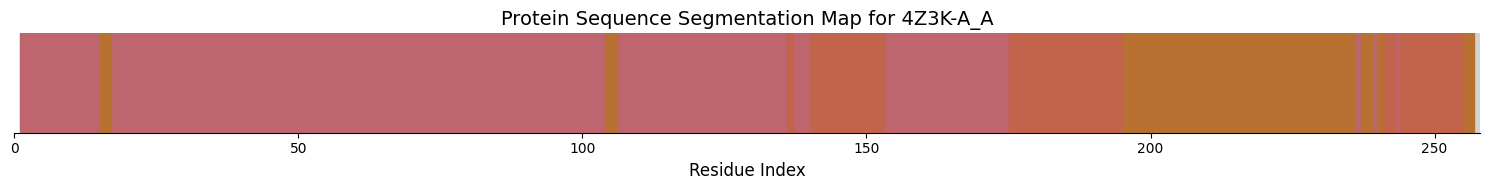

['IPR002347', 'IPR051721', 'IPR006393', 'IPR036291']
Saved plot to sdr_proteins_puffin\6CGE-A_A


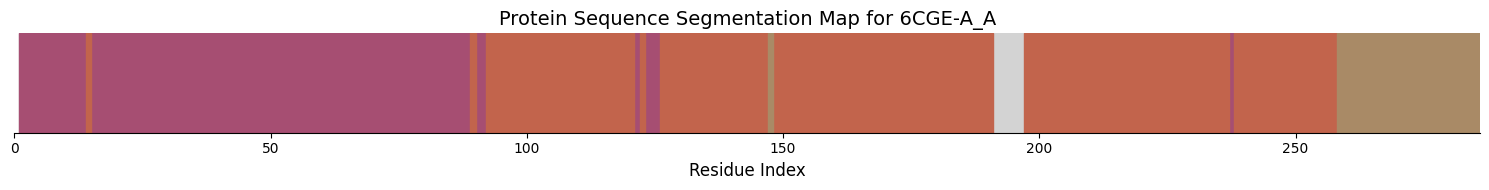

['IPR011348', 'IPR002347', 'IPR020904', 'IPR036291']
Saved plot to sdr_proteins_puffin\1E3W-A_A


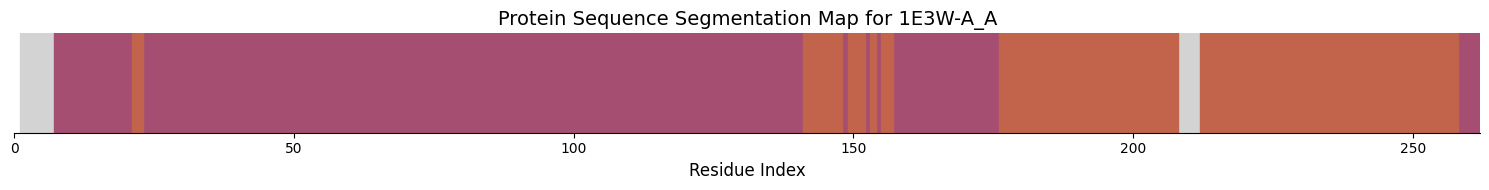

['IPR002347', 'IPR020904', 'IPR036291']
Saved plot to sdr_proteins_puffin\4CQL-A_A


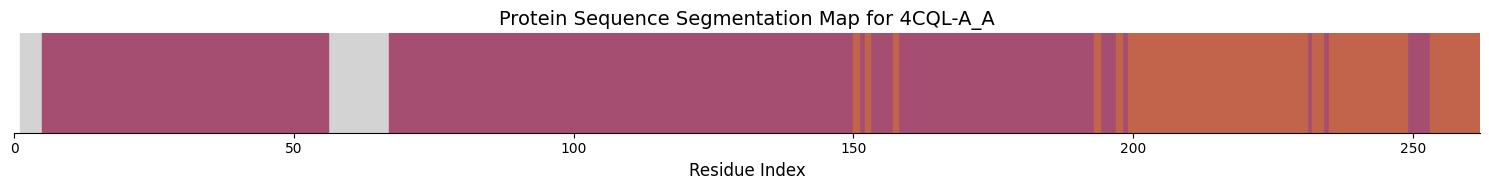

['IPR002347', 'IPR020904', 'IPR036291']
Saved plot to sdr_proteins_puffin\1MG5-A_A


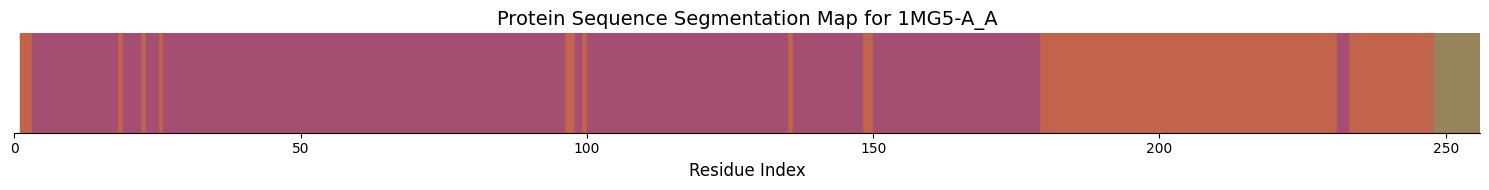

['IPR002347', 'IPR020904', 'IPR002425', 'IPR036291']
Saved plot to sdr_proteins_puffin\1AHH-A_A


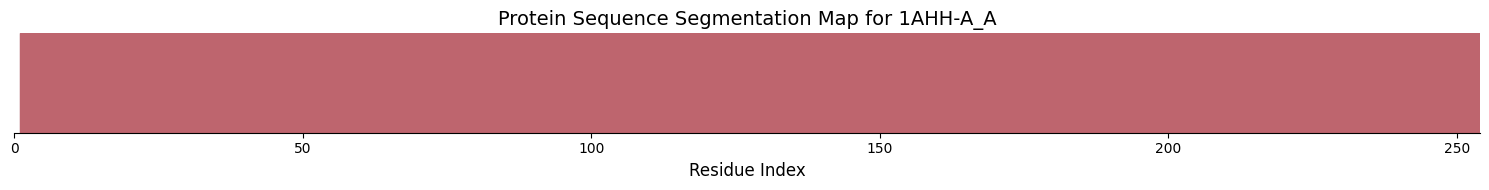

['IPR002347', 'IPR020904', 'IPR050259', 'IPR036291']
Saved plot to sdr_proteins_puffin\3O4R-A_A


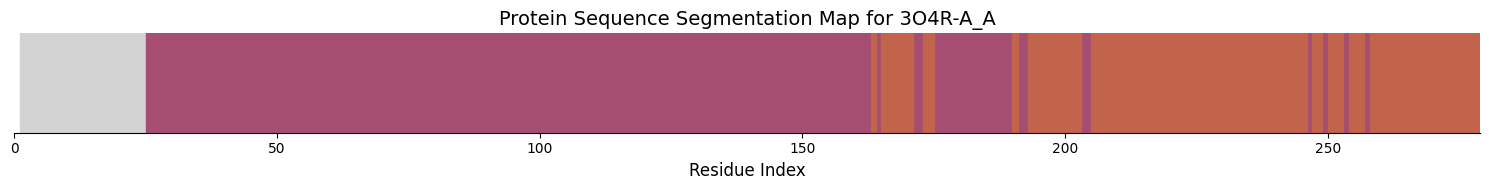

['IPR002347', 'IPR020904', 'IPR036291']
Saved plot to sdr_proteins_puffin\4HBG-A_A


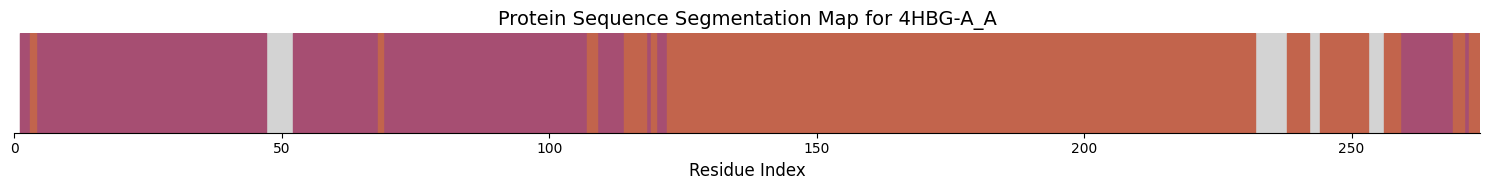

['IPR002347', 'IPR020904', 'IPR036291']
Saved plot to sdr_proteins_puffin\1W73-A_A


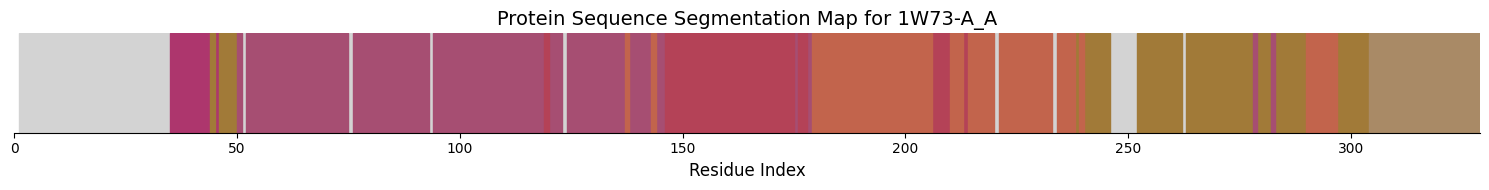

['IPR002347', 'IPR036291']
Saved plot to sdr_proteins_puffin\4FC7-A_A


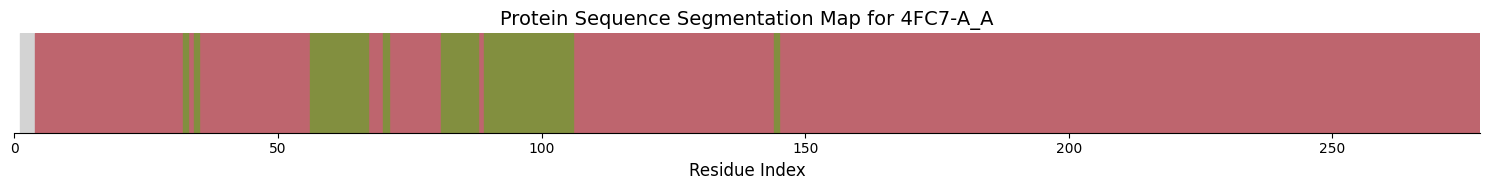

['IPR002347', 'IPR045017', 'IPR036291']
Saved plot to sdr_proteins_puffin\1DIR-A_A


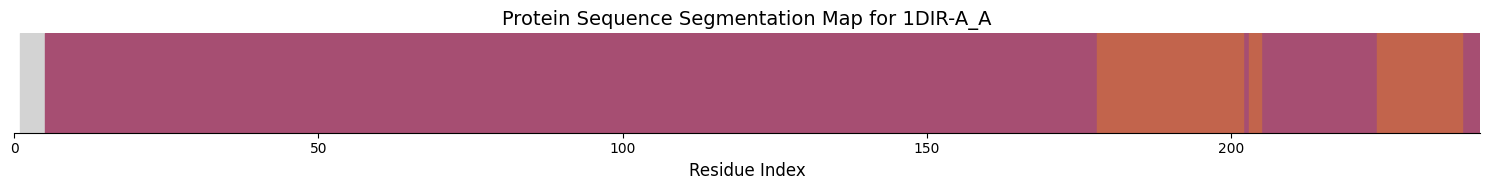

['IPR002347', 'IPR020904', 'IPR036291']
Saved plot to sdr_proteins_puffin\4CQM-B_B


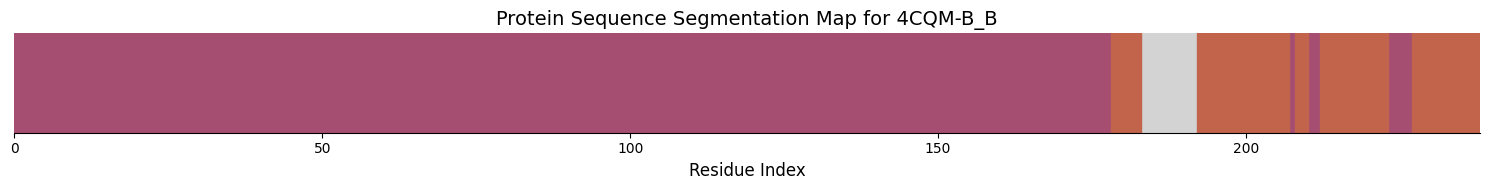

['IPR002347', 'IPR020904', 'IPR036291']
Saved plot to sdr_proteins_puffin\3D3W-A_A


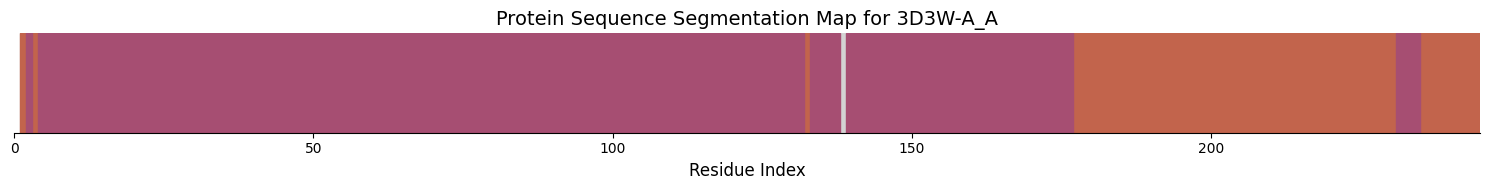

['IPR002347', 'IPR020904', 'IPR051737', 'IPR036291']
Saved plot to sdr_proteins_puffin\1Q7C-A_A


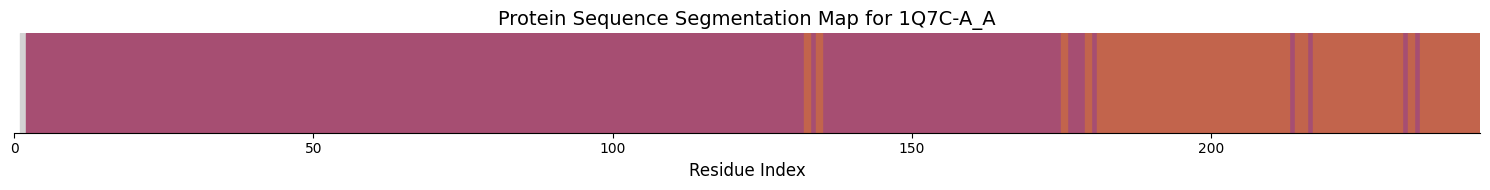

['IPR002347', 'IPR011284', 'IPR050259', 'IPR036291']
Saved plot to sdr_proteins_puffin\1YXM-A_A


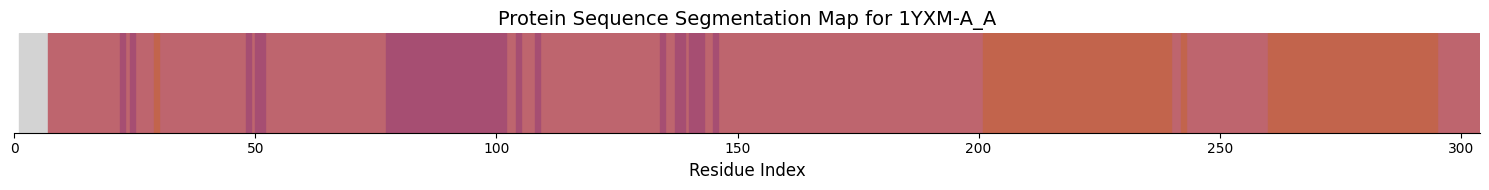

['IPR002347', 'IPR052388', 'IPR036291']
Saved plot to sdr_proteins_puffin\2O23-A_A


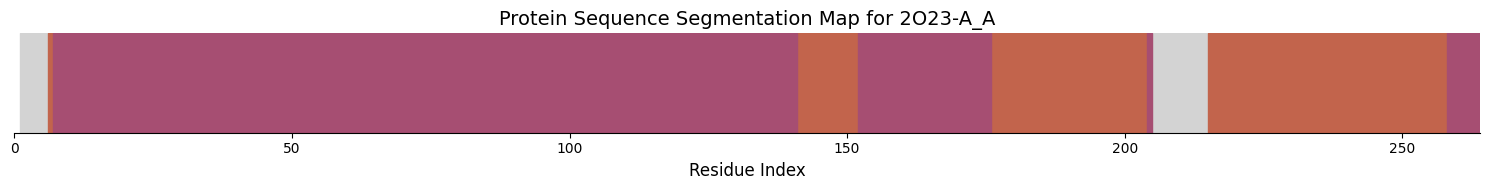

['IPR002347', 'IPR020904', 'IPR036291']
Saved plot to sdr_proteins_puffin\4HWK-A_A


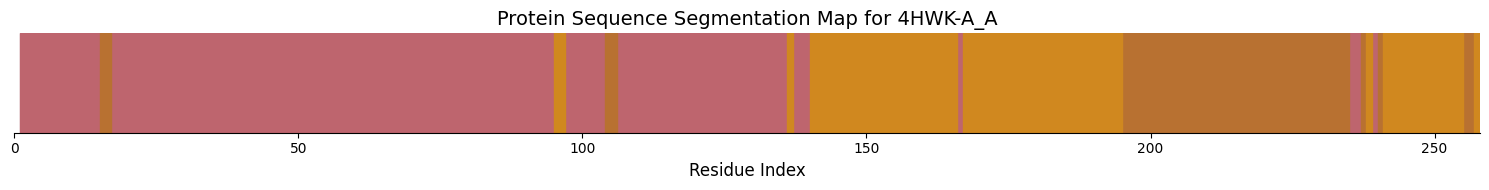

['IPR002347', 'IPR051721', 'IPR006393', 'IPR036291']


In [15]:
# create folder for images
import os
import interpro_proto_go_term_comparison as ipgtc

dir_name = "sdr_proteins_puffin"
os.makedirs(dir_name, exist_ok=True)
df_rows = []
for _, row in selected_sdr_proteins.iterrows():
    protein_id = row['protein_id']
    chain = row['chain']
    pdb_id = f"{protein_id}-{chain}_{chain}"

    try:
        residue_ids = get_residue_ids(segment_assignments_with_protos, pdb_id=pdb_id)
        proto_ids = get_proto_ids(segment_assignments_with_protos, pdb_id=pdb_id)

        proto_to_residues = group_residues_by_proto(residue_ids, proto_ids)
        proto_to_color = proto_id_to_color(proto_ids, color_model)

        max_res = max([max(res_list) for res_list in proto_to_residues.values() if res_list])

        visualize_sequence_colors(
            pdb_id,
            proto_to_residues,
            proto_to_color,
            max_res,
            filename=os.path.join(dir_name, pdb_id),
        )
        show_colors_html(proto_to_color)
        # show IPR annotations
        
        interpro_data = ipgtc.extract_interpro_intervals(interpro, protein_id, chain)
        interpro_accessions = list(set([d["accession"] for d in interpro_data]))
        print(interpro_accessions)


        df_rows.append({
            "pdb_id": pdb_id,
            "proto_ids": list(proto_to_color.keys()),
            "interpro_accessions": interpro_accessions
        })
    except Exception:
        # skip proteins that fail due to missing data or other issues
        continue

## Extracting Statistics of Clusters

In [16]:
from collections import Counter

def calculate_protein_prototype_stats(protein_proto_list):
    """
    Calculate statistics for a list of proteins and their prototypes.
    
    Args:
        protein_proto_list: List of dicts with 'pdb_id' and 'proto_ids'
    
    Returns:
        Dict with comprehensive statistics
    """
    if not protein_proto_list:
        return {}
    
    # Extract data
    pdb_ids = [item['pdb_id'] for item in protein_proto_list]
    proto_lists = [item['proto_ids'] for item in protein_proto_list]
    
    # Flatten all prototypes
    all_protos = []
    for proto_list in proto_lists:
        all_protos.extend(proto_list)
    
    # Count occurrences
    proto_counter = Counter(all_protos)
    proto_counts = [len(pl) for pl in proto_lists]
    
    # Build protein-to-prototype mapping
    proto_to_proteins = {}
    for pdb_id, proto_list in zip(pdb_ids, proto_lists):
        for proto in proto_list:
            if proto not in proto_to_proteins:
                proto_to_proteins[proto] = []
            proto_to_proteins[proto].append(pdb_id)
    
    stats = {
        'num_proteins': len(pdb_ids),
        'num_unique_prototypes': len(set(all_protos)),
        'total_prototype_assignments': len(all_protos),
        'avg_prototypes_per_protein': sum(proto_counts) / len(proto_counts),
        'min_prototypes': min(proto_counts),
        'max_prototypes': max(proto_counts),
        'median_prototypes': sorted(proto_counts)[len(proto_counts) // 2],
        'most_common_prototypes': proto_counter.most_common(10),
        'proto_count_distribution': dict(Counter(proto_counts)),
        'proto_to_proteins': proto_to_proteins,
    }
    
    return stats

# Convert to DataFrame for easier analysis and export
df_results = pd.DataFrame(df_rows)

stats = calculate_protein_prototype_stats(df_rows)

# Pretty print the results
print("=== Protein-Prototype Statistics ===\n")
print(f"Number of proteins: {stats['num_proteins']}")
print(f"Unique prototypes: {stats['num_unique_prototypes']}")
print(f"Total assignments: {stats['total_prototype_assignments']}")
print(f"Average prototypes per protein: {stats['avg_prototypes_per_protein']:.2f}")
print(f"Min prototypes: {stats['min_prototypes']}")
print(f"Max prototypes: {stats['max_prototypes']}")
print(f"Median prototypes: {stats['median_prototypes']}")
print(f"\nTop 10 most common prototypes:\n{stats['most_common_prototypes']}")
print(f"\nCount distribution (how many proteins have N prototypes):\n{stats['proto_count_distribution']}")

# Prototype co-occurrence analysis
print("\n=== Prototype Details ===")
for proto, proteins in sorted(stats['proto_to_proteins'].items(), 
                               key=lambda x: len(x[1]), reverse=True)[:15]:
    print(f"\nPrototype {proto}: appears in {len(proteins)} proteins")
    print(f"  Proteins: {', '.join(proteins[:5])}" + 
          ("..." if len(proteins) > 5 else ""))

# Save results to CSV
df_results.to_csv("protein_prototype_summary.csv", index=False)
print("\n✓ Saved results to 'protein_prototype_summary.csv'")

=== Protein-Prototype Statistics ===

Number of proteins: 25
Unique prototypes: 11
Total assignments: 57
Average prototypes per protein: 2.28
Min prototypes: 1
Max prototypes: 6
Median prototypes: 2

Top 10 most common prototypes:
[(917, 19), (670, 19), (281, 7), (652, 3), (71, 2), (711, 2), (325, 1), (399, 1), (647, 1), (561, 1)]

Count distribution (how many proteins have N prototypes):
{1: 4, 2: 13, 3: 7, 6: 1}

=== Prototype Details ===

Prototype 917: appears in 19 proteins
  Proteins: 2FWM-X_X, 3BHI-A_A, 5JS6-A_A, 2HRB-A_A, 2AG5-A_A...

Prototype 670: appears in 19 proteins
  Proteins: 3BHI-A_A, 5JS6-A_A, 2HRB-A_A, 2AG5-A_A, 2GDZ-A_A...

Prototype 281: appears in 7 proteins
  Proteins: 4JQC-A_A, 5CFZ-A_A, 4Z3K-A_A, 1AHH-A_A, 4FC7-A_A...

Prototype 652: appears in 3 proteins
  Proteins: 5JS6-A_A, 2GDZ-A_A, 1MG5-A_A

Prototype 71: appears in 2 proteins
  Proteins: 4Z3K-A_A, 4HWK-A_A

Prototype 711: appears in 2 proteins
  Proteins: 6CGE-A_A, 1W73-A_A

Prototype 325: appears in 1 pr

In [17]:
df_results

,pdb_id,proto_ids,interpro_accessions
0,2FWM-X_X,[917],"[IPR003560, IPR002347, IPR020904, IPR036291]"
1,3BHI-A_A,"[917, 670]","[IPR002347, IPR045313, IPR020904, IPR036291]"
2,4JQC-A_A,[281],"[IPR002347, IPR036291, IPR014358]"
3,5JS6-A_A,"[917, 670, 652]","[IPR002347, IPR020904, IPR036291]"
4,2HRB-A_A,"[917, 670]","[IPR002347, IPR045313, IPR020904, IPR036291]"
5,2AG5-A_A,"[917, 670]","[IPR051122, IPR002347, IPR020904, IPR036291]"
6,5CFZ-A_A,[281],"[IPR002347, IPR036291, IPR014358]"
7,2GDZ-A_A,"[670, 917, 652]","[IPR002347, IPR020904, IPR036291]"
8,4Z3K-A_A,"[281, 71, 670]","[IPR002347, IPR051721, IPR006393, IPR036291]"
9,6CGE-A_A,"[917, 670, 711]","[IPR011348, IPR002347, IPR020904, IPR036291]"


In [18]:
groups = (
    df_results.groupby(df_results["interpro_accessions"].apply(tuple))["pdb_id"]
      .apply(list)
      .reset_index(name="pdb_ids")
)
groups

,interpro_accessions,pdb_ids
0,"(IPR002347, IPR011284, IPR050259, IPR036291)",[1Q7C-A_A]
1,"(IPR002347, IPR020904, IPR002425, IPR036291)",[1MG5-A_A]
2,"(IPR002347, IPR020904, IPR036291)","[5JS6-A_A, 2GDZ-A_A, 1E3W-A_A, 4CQL-A_A, 3O4R-..."
3,"(IPR002347, IPR020904, IPR050259, IPR036291)",[1AHH-A_A]
4,"(IPR002347, IPR020904, IPR051737, IPR036291)",[3D3W-A_A]
5,"(IPR002347, IPR036291)",[1W73-A_A]
6,"(IPR002347, IPR036291, IPR014358)","[4JQC-A_A, 5CFZ-A_A]"
7,"(IPR002347, IPR045017, IPR036291)",[4FC7-A_A]
8,"(IPR002347, IPR045313, IPR020904, IPR036291)","[3BHI-A_A, 2HRB-A_A]"
9,"(IPR002347, IPR051721, IPR006393, IPR036291)","[4Z3K-A_A, 4HWK-A_A]"


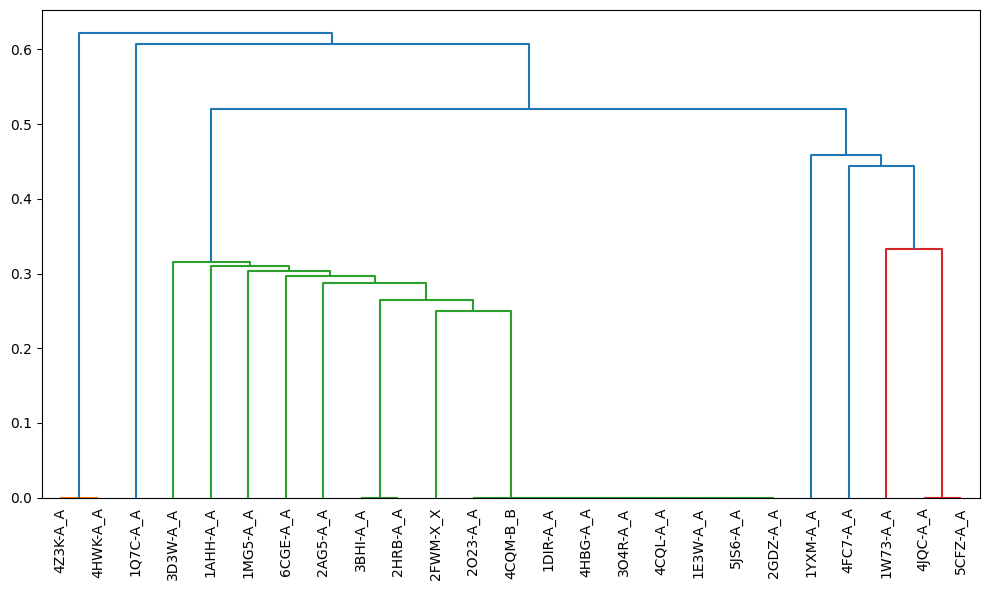

In [19]:
from sklearn.preprocessing import MultiLabelBinarizer
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# convert InterPro sets to binary matrix
mlb = MultiLabelBinarizer()
X = mlb.fit_transform(df_results["interpro_accessions"])

# hierarchical clustering with Jaccard distance
Z = linkage(X, method="average", metric="jaccard")

# plot dendrogram
plt.figure(figsize=(10,6))
dendrogram(Z, labels=df_results["pdb_id"].values, leaf_rotation=90)
plt.tight_layout()
plt.show()

In [20]:
from scipy.cluster.hierarchy import fcluster
import pandas as pd

# choose a distance threshold (0.5 is just an example)
max_d = 0.5
cluster_labels = fcluster(Z, max_d, criterion='distance')

df_results['cluster'] = cluster_labels

# see cluster composition
for c in sorted(df_results['cluster'].unique()):
    pdbs = df_results[df_results['cluster'] == c]['pdb_id'].tolist()
    # common accessions in this cluster
    accessions = df_results[df_results['cluster'] == c]['interpro_accessions']
    common = set.intersection(*map(set, accessions))
    print(f"Cluster {c}: {len(pdbs)} PDBs, common accessions: {common}")

Cluster 1: 2 PDBs, common accessions: {'IPR002347', 'IPR051721', 'IPR006393', 'IPR036291'}
Cluster 2: 17 PDBs, common accessions: {'IPR002347', 'IPR020904', 'IPR036291'}
Cluster 3: 5 PDBs, common accessions: {'IPR002347', 'IPR036291'}
Cluster 4: 1 PDBs, common accessions: {'IPR002347', 'IPR011284', 'IPR050259', 'IPR036291'}


In [21]:
def calculate_all_proto_enrichments(protein_proto_list, enrichment_df):

    df_res = pd.DataFrame()
    if not protein_proto_list:
        return {}
    
    # Extract data
    proto_lists = [item['proto_ids'] for item in protein_proto_list]
    
    # Flatten all prototypes
    all_protos = []
    for proto_list in proto_lists:
        all_protos.extend(proto_list)

    for proto in set(all_protos):
        df_res = pd.concat([df_res, enrichment_df[enrichment_df["proto"] == proto].sort_values("qval").head(3)])
    
    return df_res

In [22]:
calculate_all_proto_enrichments(df_rows, enrichment_df)

,proto,go_term,a_in_has,b_in_not,c_out_has,d_out_not,proto_proteins,total_proteins,pval,odds_ratio_approx,qval
23154,325,GO:0036361,21,0,52,28907,21,28980,1.103449e-56,inf,1.097066e-54
23155,325,GO:0016855,21,0,65,28894,21,28980,5.848613e-55,inf,5.628516e-53
23156,325,GO:0047661,20,1,47,28912,21,28980,1.704941e-53,1.230298e+04,1.574973e-51
4961,71,GO:0016836,22,299,346,28313,321,28980,1.931343e-10,6.020898e+00,3.239124e-09
4962,71,GO:0016616,26,295,513,28146,321,28980,4.471789e-10,4.835603e+00,7.280670e-09
4963,71,GO:0008374,9,312,36,28623,321,28980,1.401136e-09,2.293510e+01,2.195368e-08
48954,711,GO:0016627,24,294,217,28445,318,28980,3.326802e-16,1.070065e+01,8.029177e-15
48955,711,GO:0050660,26,292,330,28332,318,28980,3.311613e-14,7.644583e+00,7.128530e-13
48956,711,GO:0046906,26,292,727,27935,318,28980,3.150275e-07,3.421407e+00,3.928492e-06
45041,647,GO:0036361,21,1,52,28906,22,28980,2.423426e-55,1.167358e+04,2.355189e-53
